In [1]:
import os
import random
import numpy as np
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["TF_DETERMINISTIC_OPS"] = "1"
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

In [2]:
df = pd.read_csv("karaikal.csv")
df = df.dropna()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)
df.head()
df["hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [3]:
model = load_model("../../lstm_transfer_pretrained_2010_2020.keras")

feature_scaler = joblib.load("../../feature_scaler_2010_2020.save")
target_scaler  = joblib.load("../../target_scaler_2010_2020.save")

print("Model input shape:", model.input_shape)

Model input shape: (None, 12, 7)


In [4]:
feature_cols = [
    "temperature",
    "dewpoint",
    "pressure",
    "wind_u",
    "wind_v",
    "cloud_cover",
    "humidity"
]

target_col = "rain_mm"

X_raw = df[feature_cols]
y_raw = df[[target_col]]

# Scale using pretrained scalers
X_scaled = feature_scaler.transform(X_raw)
y_scaled = target_scaler.transform(y_raw)

In [5]:
sequence_length = 12

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)

print(X_seq.shape, y_seq.shape)

(7292, 12, 7) (7292, 1)


In [6]:
split = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.9022 - mae: 0.3365 - val_loss: 1.4037 - val_mae: 0.3344
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.8848 - mae: 0.3282 - val_loss: 1.3865 - val_mae: 0.3407
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.8814 - mae: 0.3271 - val_loss: 1.3881 - val_mae: 0.3027
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.8785 - mae: 0.3321 - val_loss: 1.3748 - val_mae: 0.3050
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.8688 - mae: 0.3244 - val_loss: 1.3928 - val_mae: 0.3126
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.8661 - mae: 0.3256 - val_loss: 1.3768 - val_mae: 0.3054
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.8580 - mae: 0.3199 - val_loss: 1.3878 - val_mae: 0.3361
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.8665 - mae: 0.3270 - val_loss: 1.3641 - val_mae: 0.3088
Epoch 9/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.850

In [8]:
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output 
)

train_embed = feature_extractor.predict(X_train)
test_embed  = feature_extractor.predict(X_test)

print("Embedding shape:", train_embed.shape)

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Embedding shape: (5833, 16)


In [9]:

X_original = df[feature_cols].iloc[sequence_length:].reset_index(drop=True)

X_original_train = X_original.iloc[:split]
X_original_test  = X_original.iloc[split:]

In [10]:
# Convert to numpy
X_original_train_np = X_original_train.values
X_original_test_np  = X_original_test.values

# Concatenate
X_train_hybrid = np.concatenate([train_embed, X_original_train_np], axis=1)
X_test_hybrid  = np.concatenate([test_embed, X_original_test_np], axis=1)

print(X_train_hybrid.shape)

(5833, 23)


In [11]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    gamma=0.1,
    n_jobs=-1
)

xgb.fit(X_train_hybrid, y_train.ravel())

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [12]:
y_pred_scaled = xgb.predict(X_test_hybrid).reshape(-1, 1)

# Convert back to real rainfall
y_test_real = target_scaler.inverse_transform(y_test)
y_pred_real = target_scaler.inverse_transform(y_pred_scaled)

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

mae = mean_absolute_error(y_test_real, y_pred_real)
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred_real)
medae = median_absolute_error(y_test_real, y_pred_real)

print("\nImproved Hybrid Transfer Model Metrics")
print("MAE   :", round(mae, 4), "mm")
print("MSE   :", round(mse, 4))
print("RMSE  :", round(rmse, 4), "mm")
print("R²    :", round(r2, 4))
print("MedAE :", round(medae, 4), "mm")


Improved Hybrid Transfer Model Metrics
MAE   : 0.1091 mm
MSE   : 0.1787
RMSE  : 0.4227 mm
R²    : 0.08
MedAE : 0.0196 mm


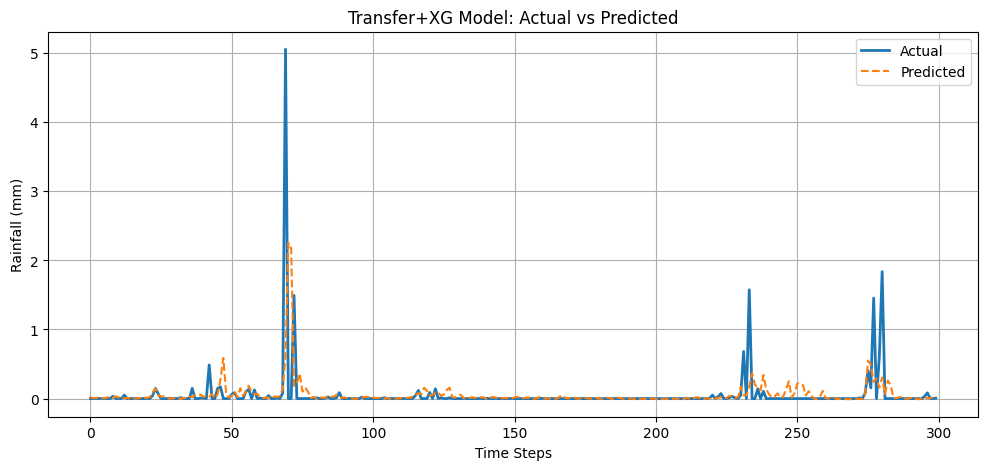

In [14]:
plt.figure(figsize=(12,5))

plt.plot(y_test_real[:300], label="Actual", linewidth=2)
plt.plot(y_pred_real[:300], label="Predicted", linestyle="--")

plt.xlabel("Time Steps")
plt.ylabel("Rainfall (mm)")
plt.title("Transfer+XG Model: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# Take last 12 timesteps
sample_sequence = X_scaled[-sequence_length:]

# Reshape for LSTM
sample_sequence = sample_sequence.reshape(1, sequence_length, -1)

# LSTM embedding
sample_embed = feature_extractor.predict(sample_sequence)

# Last timestep original features
sample_original = X_raw.iloc[-1].values.reshape(1, -1)

# Combine
sample_hybrid = np.concatenate([sample_embed, sample_original], axis=1)

# Predict
pred_scaled = xgb.predict(sample_hybrid).reshape(-1, 1)

# Convert to mm
pred_real = target_scaler.inverse_transform(pred_scaled)

print("Predicted Rainfall (next timestep):", round(pred_real[0][0], 4), "mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Rainfall (next timestep): 0.2007 mm


In [16]:
import joblib

model.save("lstm_finetuned.keras")
joblib.dump(feature_scaler, "feature_scaler.save")
joblib.dump(target_scaler, "target_scaler.save")
joblib.dump(xgb, "xgb_model.save")

print("Saved all models")


Saved all models


In [17]:
metrics = {
    "MAE": float(mae),
    "MSE": float(mse),
    "RMSE": float(rmse),
    "R2": float(r2),
    "MedAE": float(medae)
}

joblib.dump(metrics, "metrics.save")
results_df = pd.DataFrame({
    "actual": y_test_real.flatten(),
    "predicted": y_pred_real.flatten()
})

results_df.to_csv("graph_data.csv", index=False)